In [1]:
from pydantic import BaseModel
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from langchain.agents import create_tool_calling_agent, AgentExecutor
from dotenv import load_dotenv
import os
load_dotenv()

True

In [2]:
from supabase import create_client, Client
from supabase.client import ClientOptions

url: str = os.environ.get("SUPABASE_URL")
key: str = os.environ.get("SUPABASE_KEY")
supabase_client: Client = create_client(
    url, 
    key,
    options=ClientOptions(
        postgrest_client_timeout=10,
        storage_client_timeout=10,
        schema="public",
    )
)

In [61]:
def _execute_supabase_query(query:str) -> str:
    """
        Execute posgresql query in supabase to table Task. You can do all function following this table detail:
        public.task (
            id int4 GENERATED BY DEFAULT AS IDENTITY NOT NULL,
            user_id text NOT NULL DEFAULT ''::text,
            title text NOT NULL,
            description text NOT NULL,
            is_completed boolean NOT NULL,
            due_date text NOT NULL,
            priority int2 NOT NULL,
            created_at timestamp with time zone NOT NULL DEFAULT now(),
            updated_at timestamp without time zone NULL,
            CONSTRAINT task_pkey PRIMARY KEY (id)
        );

        the query is not support ";" character so please do not use it
        Args:
            query: postgresql query to execute
    """
    return_msg = ""
    try:
        response = supabase_client.rpc("execute_raw_query", {"query": query}).execute()
        return_msg = "Success execute query."
        if response.data:
            return_msg = f"{return_msg}\n{str(response.data)}"
        return return_msg
    except Exception as e:
        return_msg = f"Failed to execute query with error: {e}"
        return return_msg
    
tools = [_execute_supabase_query]

In [60]:
supabase_client.rpc("execute_raw_query", {"query": "SELECT * FROM task"}).execute()

SingleAPIResponse[TypeVar](data=[{'result': [{'id': 5, 'title': 'Go to campus', 'user_id': 'alfar_', 'due_date': '2025-04-20 09:00:00', 'priority': 1, 'created_at': '2025-04-18T17:52:59.590981+00:00', 'updated_at': '2025-04-18T17:52:59.590981', 'description': 'Go to campus tomorrow', 'is_completed': False}]}], count=None)

In [62]:
_execute_supabase_query("SELECT * FROM task")

"Success execute query.\n[{'result': [{'id': 5, 'title': 'Go to campus', 'user_id': 'alfar_', 'due_date': '2025-04-20 09:00:00', 'priority': 1, 'created_at': '2025-04-18T17:52:59.590981+00:00', 'updated_at': '2025-04-18T17:52:59.590981', 'description': 'Go to campus tomorrow', 'is_completed': False}]}]"

In [63]:
from langchain_groq import ChatGroq
model_name = "llama-3.3-70b-versatile"
llm = ChatGroq(api_key=os.getenv("GROQ_API_KEY"), model_name=model_name)
llm_with_tools = llm.bind_tools(tools)

In [64]:
from langgraph.graph import StateGraph, START
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def call_llm_node(state: MessagesState):
    """Fungsi internal untuk memanggil model"""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": response}

graph = StateGraph(state_schema=MessagesState)
graph.add_node("assistant", call_llm_node)
graph.add_node("tools", ToolNode(tools))

# Setup edge
graph.add_edge(START, "assistant")
graph.add_conditional_edges("assistant",tools_condition)
graph.add_edge("tools", "assistant")
graph = graph.compile()

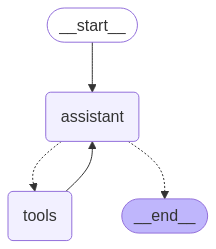

In [65]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [67]:
from langchain_core.messages import HumanMessage
# messages = [HumanMessage(content="Hello, give me random number")]
# messages = [HumanMessage(content="Hello, give me random number between 4 and 20.")]
messages = [HumanMessage(content="Hello, can you get all my task data on database and show with beautifull format data")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, can you get all my task data on database and show with beautifull format data
================================== Ai Message ==================================
Tool Calls:
  _execute_supabase_query (call_t3bp)
 Call ID: call_t3bp
  Args:
    query: SELECT * FROM task ORDER BY id DESC
================================= Tool Message =================================
Name: _execute_supabase_query

Success execute query.
[{'result': [{'id': 5, 'title': 'Go to campus', 'user_id': 'alfar_', 'due_date': '2025-04-20 09:00:00', 'priority': 1, 'created_at': '2025-04-18T17:52:59.590981+00:00', 'updated_at': '2025-04-18T17:52:59.590981', 'description': 'Go to campus tomorrow', 'is_completed': False}]}]
================================== Ai Message ==================================

Here is your task data:

* ID: 5
* Title: Go to campus
* User ID: alfar_
* Due Date: 2025-04-20 09:00:00
* Priority: 1
* Created At